<a href="https://colab.research.google.com/github/govindp29/Codencanvas/blob/main/HNS_Unit2_project_codencanvas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. Generating Enterprise Banking Data ---
Successfully generated BI database for 5000 customers.

--- 2. Business Intelligence Summary ---
# A tibble: 3 × 5
  Customer_Segment Total_Clients Avg_Account_Balance Avg_Credit_Score
  <chr>                    <int>               <dbl>            <dbl>
1 Standard                  3092               5126.             649.
2 Premium                   1418               5027.             649.
3 Wealth/HNI                 490               4859.             648.
# ℹ 1 more variable: Max_Balance <dbl>

--- 3. Generating BI Visualizations ---


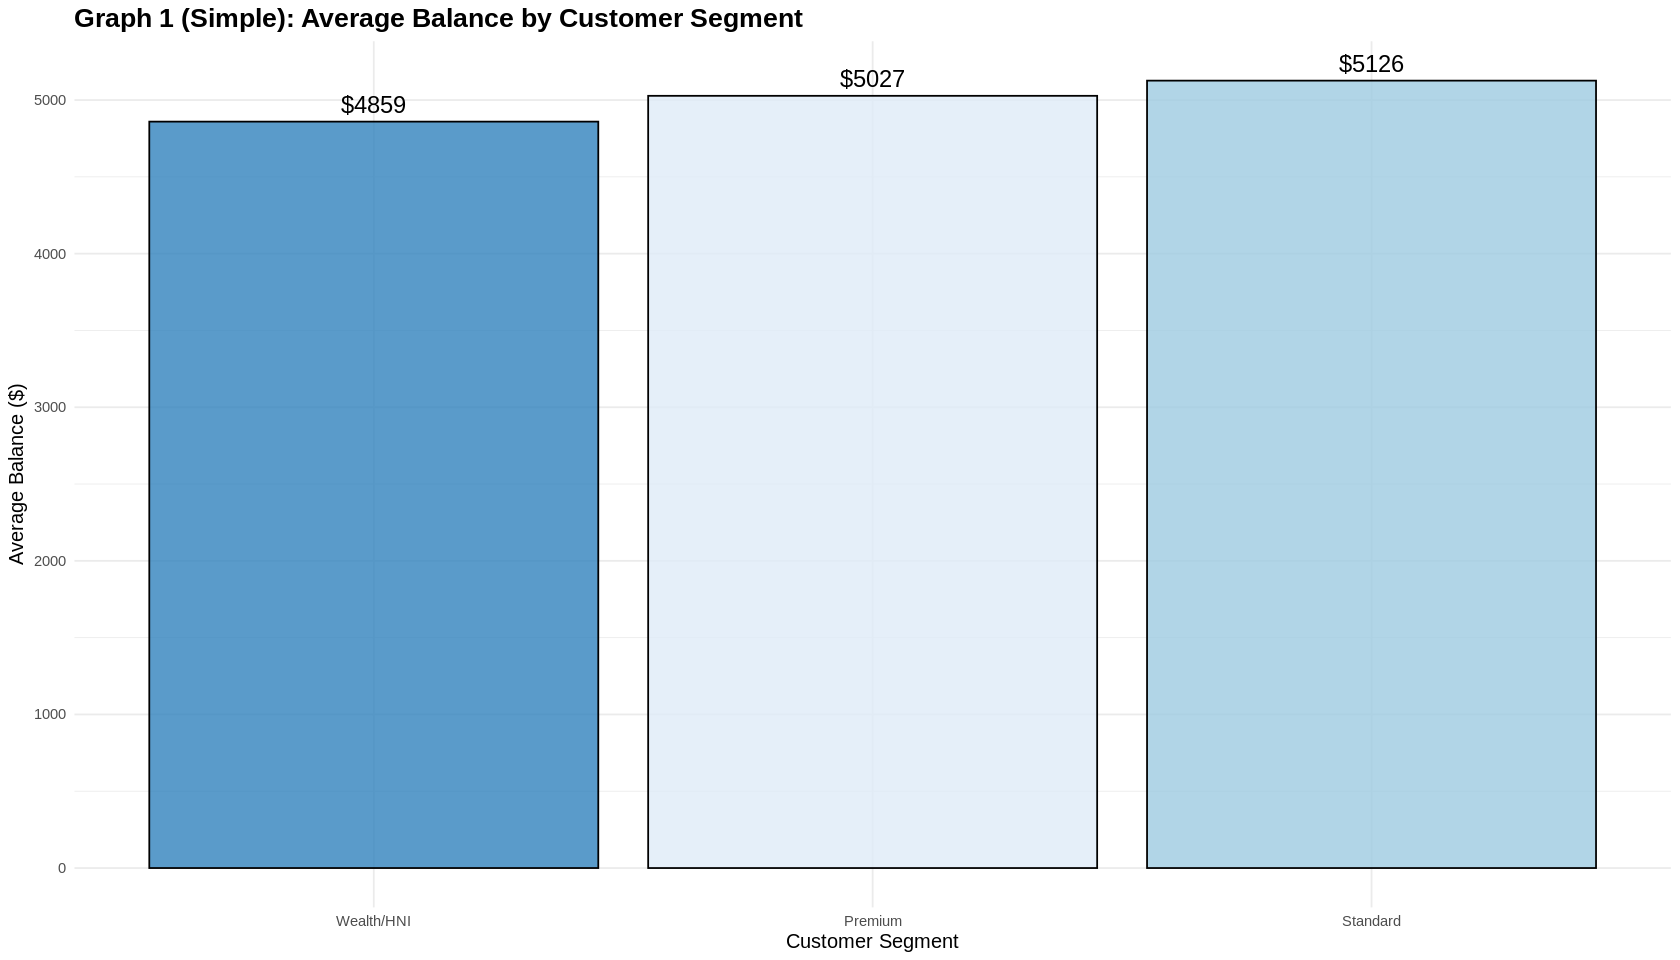

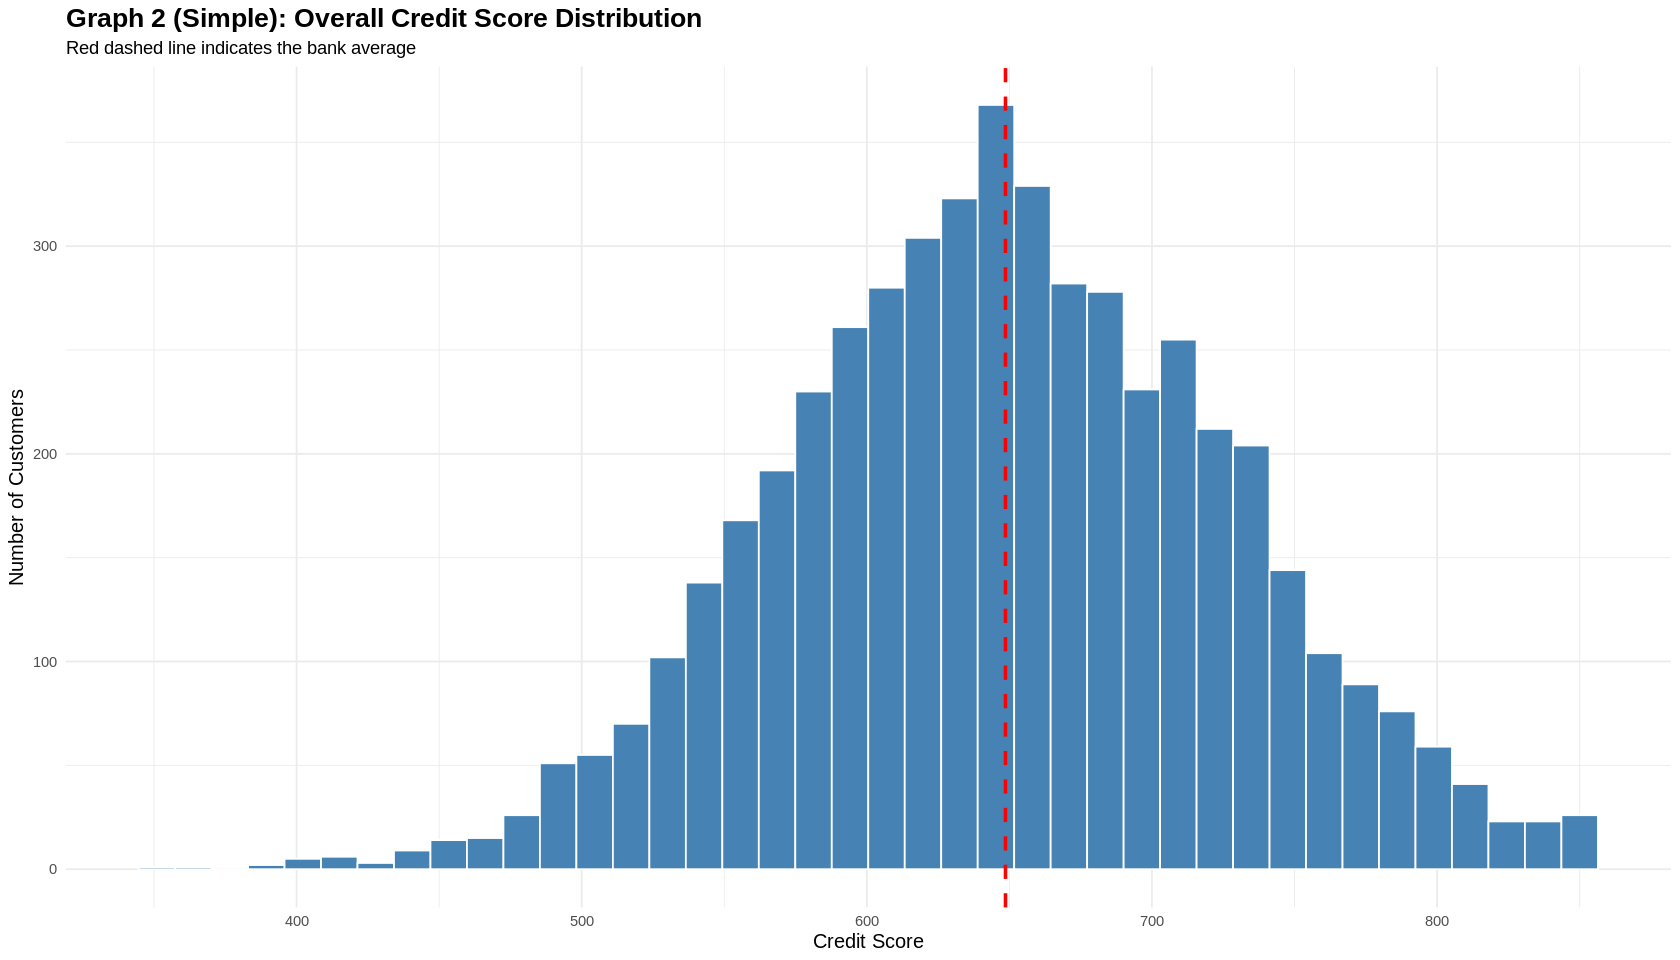

`geom_smooth()` using formula = 'y ~ x'


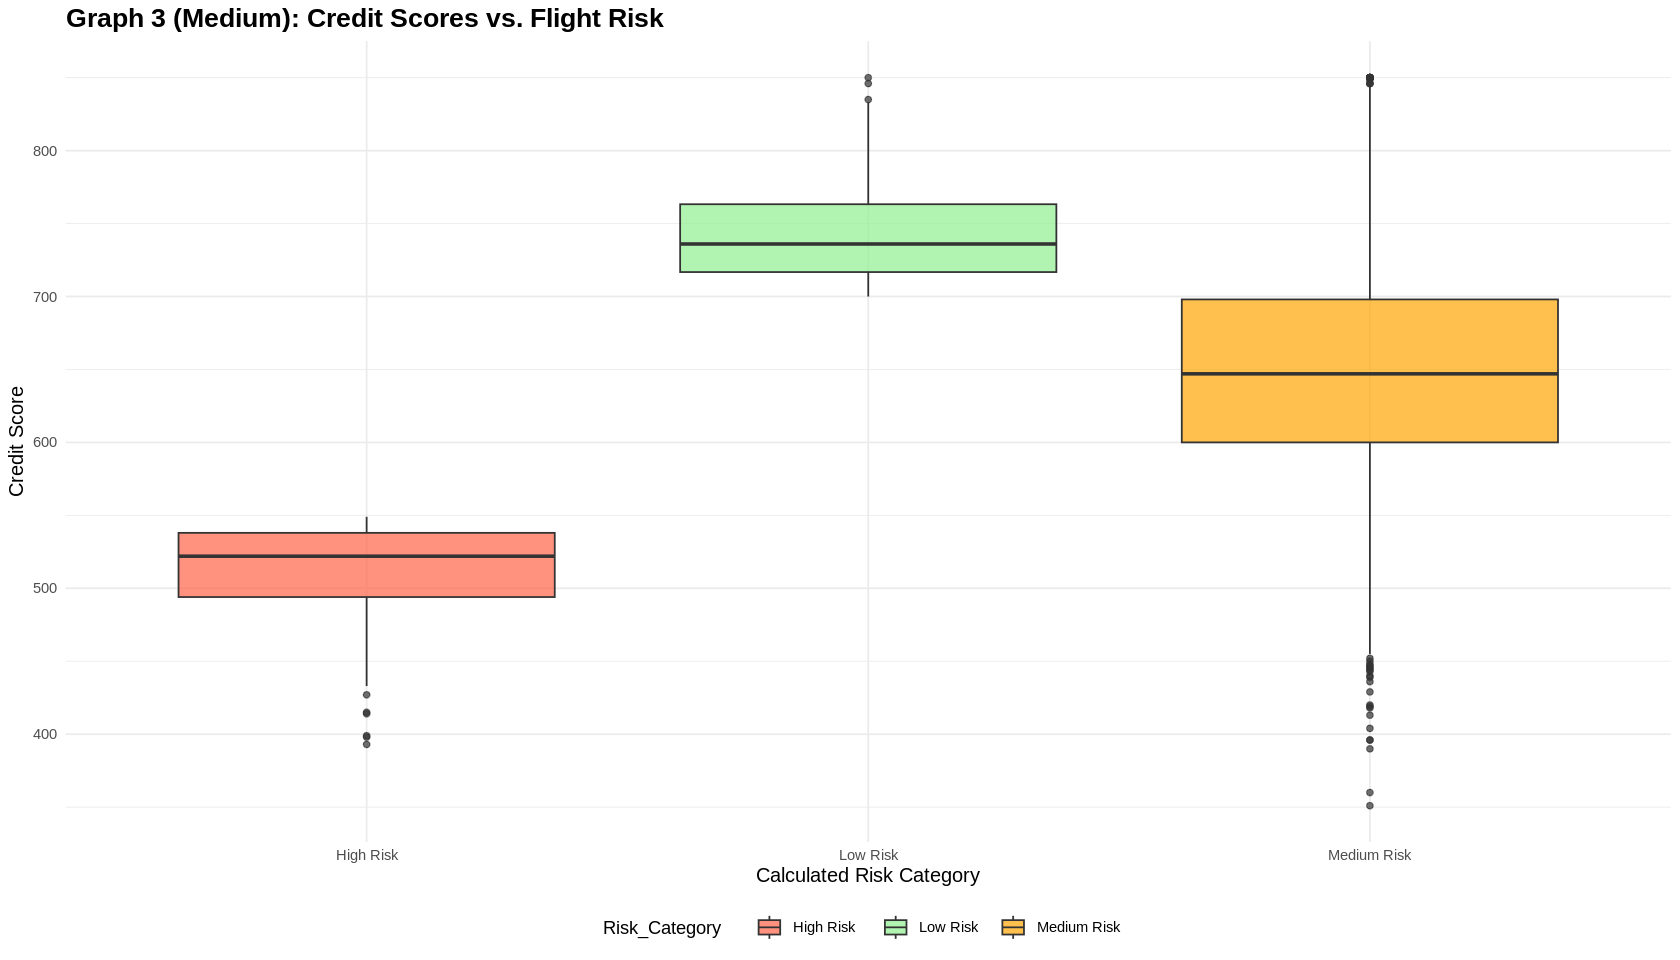

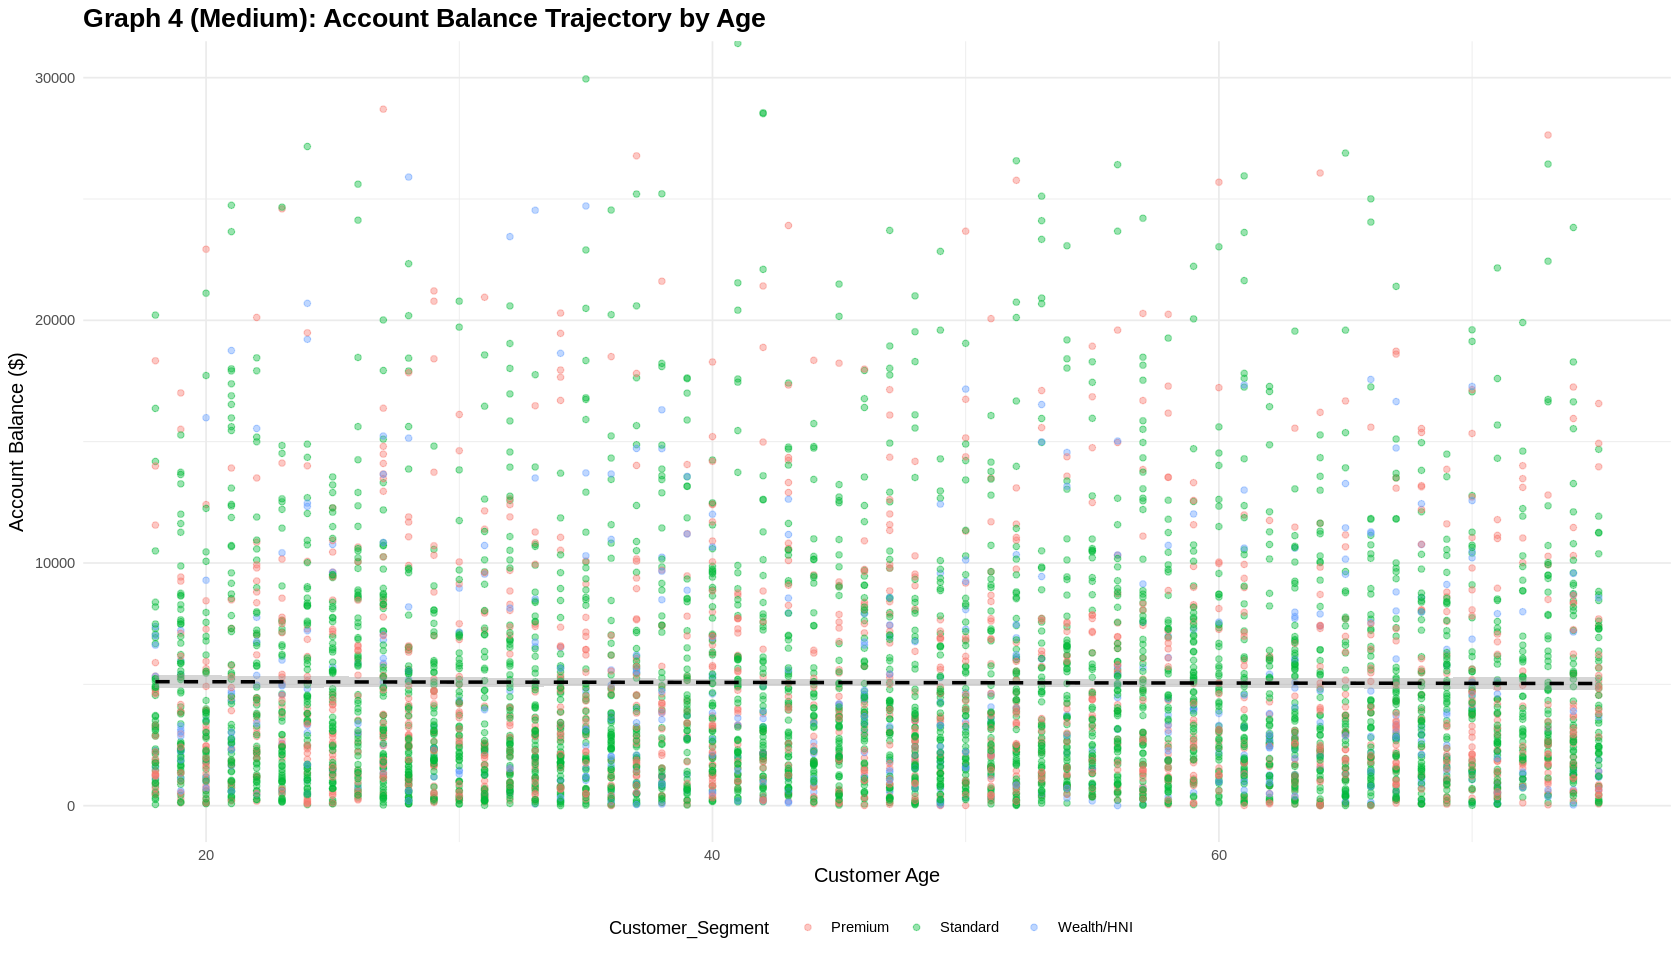


All BI visualizations rendered successfully!


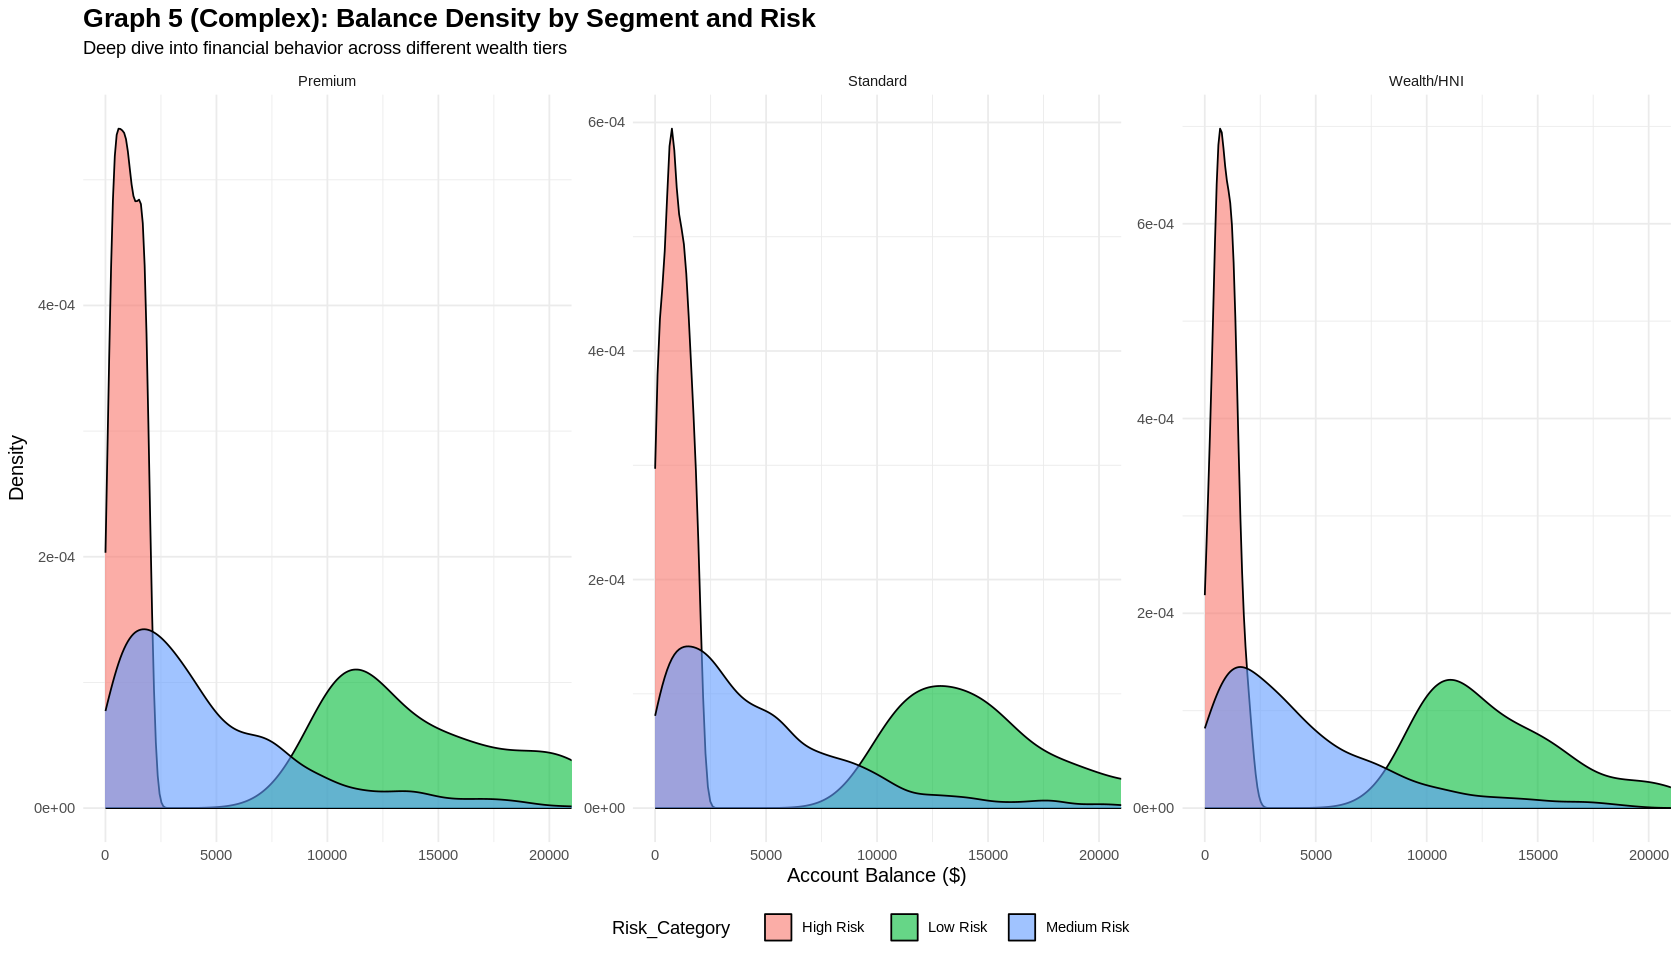

In [ ]:
# =====================================================================
# CAPSTONE PROJECT: Business Intelligence & Banking Analytics
# =====================================================================



# Load required libraries
library(ggplot2)
library(dplyr)

# Force the compiler to display BIG, widescreen graphs
options(repr.plot.width = 14, repr.plot.height = 8)
theme_set(theme_minimal(base_size = 14))


# ---------------------------------------------------------
# PART 1: DATA ENGINEERING & SIMULATION (STUDENT 1)
# ---------------------------------------------------------
cat("--- 1. Generating Enterprise Banking Data ---\n")

# Setting a seed so the random data is the same every time you run it
set.seed(123)
total_customers <- 5000

# Generating a realistic synthetic dataset for 5,000 bank customers
bank_data <- data.frame(
  CustomerID = 1:total_customers,
  Age = sample(18:75, total_customers, replace = TRUE),
  Credit_Score = round(rnorm(total_customers, mean = 650, sd = 80)),
  Account_Balance = round(rexp(total_customers, rate = 0.0002)),
  Active_Services = sample(1:5, total_customers, replace = TRUE),
  Customer_Segment = sample(c("Standard", "Premium", "Wealth/HNI"), total_customers,
                            replace = TRUE, prob = c(0.6, 0.3, 0.1))
)

# Clean up anomalies (fixing any impossible credit scores)
bank_data$Credit_Score <- ifelse(bank_data$Credit_Score > 850, 850, bank_data$Credit_Score)
bank_data$Credit_Score <- ifelse(bank_data$Credit_Score < 300, 300, bank_data$Credit_Score)

# Add a calculated column: Churn Risk based on balance and credit score
bank_data <- bank_data %>%
  mutate(Risk_Category = case_when(
    Credit_Score < 550 & Account_Balance < 2000 ~ "High Risk",
    Credit_Score >= 700 & Account_Balance > 10000 ~ "Low Risk",
    TRUE ~ "Medium Risk"
  ))

cat("Successfully generated BI database for", nrow(bank_data), "customers.\n")

# ---------------------------------------------------------
# PART 2: CORE BUSINESS ANALYTICS (STUDENT 2)
# ---------------------------------------------------------
cat("\n--- 2. Business Intelligence Summary ---\n")

# Group data by Customer Segment to find average balances and scores
bi_summary <- bank_data %>%
  group_by(Customer_Segment) %>%
  summarise(
    Total_Clients = n(),
    Avg_Account_Balance = mean(Account_Balance),
    Avg_Credit_Score = mean(Credit_Score),
    Max_Balance = max(Account_Balance)
  ) %>%
  arrange(desc(Avg_Account_Balance))

print(bi_summary)

# ---------------------------------------------------------
# PART 3: VISUALIZATION DASHBOARD (STUDENT 3)
# ---------------------------------------------------------
cat("\n--- 3. Generating BI Visualizations ---\n")

# Set a professional corporate theme for all graphs
theme_set(theme_minimal() +
          theme(plot.title = element_text(face = "bold", size = 16),
                axis.title = element_text(size = 12),
                legend.position = "bottom"))

# --- GRAPH 1: Simple Bar Chart (Wealth Distribution) ---
plot1 <- ggplot(bi_summary, aes(x = reorder(Customer_Segment, Avg_Account_Balance),
                                y = Avg_Account_Balance, fill = Customer_Segment)) +
  geom_col(color = "black", alpha = 0.8) +
  geom_text(aes(label = paste0("$", round(Avg_Account_Balance, 0))), vjust = -0.5, size = 5) +
  labs(title = "Graph 1 (Simple): Average Balance by Customer Segment",
       x = "Customer Segment", y = "Average Balance ($)") +
  scale_fill_brewer(palette = "Blues") +
  theme(legend.position = "none")

# --- GRAPH 2: Simple Histogram (Credit Score Health) ---
plot2 <- ggplot(bank_data, aes(x = Credit_Score)) +
  geom_histogram(bins = 40, fill = "steelblue", color = "white") +
  geom_vline(aes(xintercept = mean(Credit_Score)), color = "red", linetype = "dashed", linewidth = 1) +
  labs(title = "Graph 2 (Simple): Overall Credit Score Distribution",
       subtitle = "Red dashed line indicates the bank average",
       x = "Credit Score", y = "Number of Customers")

# --- GRAPH 3: Medium Boxplot (Risk Categories) ---
plot3 <- ggplot(bank_data, aes(x = Risk_Category, y = Credit_Score, fill = Risk_Category)) +
  geom_boxplot(alpha = 0.7) +
  labs(title = "Graph 3 (Medium): Credit Scores vs. Flight Risk",
       x = "Calculated Risk Category", y = "Credit Score") +
  scale_fill_manual(values = c("High Risk" = "tomato", "Medium Risk" = "orange", "Low Risk" = "lightgreen"))

# --- GRAPH 4: Medium Scatter Plot (Age vs Balance) ---
plot4 <- ggplot(bank_data, aes(x = Age, y = Account_Balance, color = Customer_Segment)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", color = "black", linetype = "dashed") +
  labs(title = "Graph 4 (Medium): Account Balance Trajectory by Age",
       x = "Customer Age", y = "Account Balance ($)") +
  coord_cartesian(ylim = c(0, 30000)) # Zoom in to ignore extreme outliers

# --- GRAPH 5: Complex Faceted Density Plot (Pro Level) ---
plot5 <- ggplot(bank_data, aes(x = Account_Balance, fill = Risk_Category)) +
  geom_density(alpha = 0.6) +
  facet_wrap(~Customer_Segment, scales = "free") +
  labs(title = "Graph 5 (Complex): Balance Density by Segment and Risk",
       subtitle = "Deep dive into financial behavior across different wealth tiers",
       x = "Account Balance ($)", y = "Density") +
  coord_cartesian(xlim = c(0, 20000))

# Display all plots back-to-back
print(plot1)
print(plot2)
print(plot3)
print(plot4)
print(plot5)

cat("\nAll BI visualizations rendered successfully!\n")